# Prophet Forecasting US Drug Overdose Deaths



In [1]:
%pip install prophet           
%pip install statsmodels


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: /opt/homebrew/opt/python@3.10/bin/python3.10 -m pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.

[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: /opt/homebrew/opt/python@3.10/bin/python3.10 -m pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
import warnings
from prophet import Prophet
from sklearn.metrics import mean_absolute_error, mean_squared_error

np.random.seed(42)
os.makedirs('../../outputs', exist_ok=True)

In [3]:
df = pd.read_csv('../../data/processed/cleaned_drug_overdose_deaths.csv')
df['Death Count'] = pd.to_numeric(df['Death Count'].astype(str).str.replace(',', ''), errors='coerce')
df['Date'] = pd.to_datetime(df['Date'])
print(df.shape)
df.head()

(47365, 8)


,State,Indicator,Date,Death Count,Percent Complete,Percent Pending Investigation,State Name,Predicted Value
0,AK,Cocaine (T40.5),2016-04-01,11,100,0.000000,Alaska,11
1,AK,Cocaine (T40.5),2016-05-01,11,100,0.000000,Alaska,11
2,AK,Cocaine (T40.5),2016-06-01,11,100,0.000000,Alaska,11
3,AK,Cocaine (T40.5),2016-07-01,13,100,0.000000,Alaska,13
4,AK,Cocaine (T40.5),2016-08-01,12,100,0.023386,Alaska,12


In [ ]:
indicator = 'Synthetic opioids, excl. methadone (T40.4)'

counts = df[df['Indicator'] == indicator].groupby('State')['Death Count'].count()
eligible_states = counts[(counts >= 80) & (~counts.index.isin(['US', 'YC']))].index.tolist()
print(f'{len(eligible_states)} eligible states: {eligible_states}')

30 eligible states: ['AK', 'AZ', 'CO', 'CT', 'DC', 'DE', 'GA', 'IA', 'IL', 'KY', 'MA', 'MD', 'ME', 'MO', 'NH', 'NM', 'NV', 'OH', 'OK', 'OR', 'RI', 'SC', 'SD', 'TN', 'UT', 'VA', 'VT', 'WA', 'WI', 'WY']


In [ ]:
def prep_yoy(df, state, indicator):
    subset = df[(df['State'] == state) & (df['Indicator'] == indicator)].copy()
    subset = subset.sort_values('Date').reset_index(drop=True)
    subset['yoy'] = subset['Death Count'] - subset['Death Count'].shift(12)
    subset = subset.dropna(subset=['yoy'])
    subset = subset[subset['yoy'] >= 0].copy()
    subset = subset.rename(columns={'Date': 'ds'})
    subset['y'] = subset['yoy']
    return subset[['ds', 'y']].reset_index(drop=True)

In [ ]:
def run_prophet(df, state, indicator):
    data = prep_yoy(df, state, indicator)

    if len(data) < 24:
        return None

    m = Prophet(yearly_seasonality=True, weekly_seasonality=False, daily_seasonality=False)
    m.fit(data)


    from prophet.diagnostics import cross_validation, performance_metrics
    cv = cross_validation(m, initial='730 days', period='180 days', horizon='90 days', parallel=None)
    pm = performance_metrics(cv)
    mae = pm['mae'].mean()
    rmse = pm['rmse'].mean()


    future = m.make_future_dataframe(periods=3, freq='MS')
    forecast = m.predict(future)

    last_fitted = forecast[forecast['ds'] == data['ds'].max()]['yhat'].values[0]
    future_only = forecast[forecast['ds'] > data['ds'].max()]
    projected_change = future_only['yhat'].mean() - last_fitted
    if len(future_only) == 0:
        projected_change = 0
    else:
        projected_change = future_only['yhat'].mean() - last_fitted

    return {
        'state': state,
        'mae': mae,
        'rmse': rmse,
        'projected_change': projected_change,
        'forecast': forecast,
        'actual': data,
        'train_end': data['ds'].max()
    }

In [24]:
results = {}

for state in eligible_states:
    result = run_prophet(df, state, indicator)
    if result:
        results[state] = result
        print(f"{state}: MAE={result['mae']:.1f}, RMSE={result['rmse']:.1f}, projected change={result['projected_change']:+.1f}")
    else:
        print(f"{state}: skipped (insufficient data)")

print(f'\n{len(results)} states modeled.')

11:53:34 - cmdstanpy - INFO - Chain [1] start processing
11:53:34 - cmdstanpy - INFO - Chain [1] done processing


  0%|          | 0/11 [00:00<?, ?it/s]

11:53:35 - cmdstanpy - INFO - Chain [1] start processing
11:53:35 - cmdstanpy - INFO - Chain [1] done processing
11:53:35 - cmdstanpy - INFO - Chain [1] start processing
11:53:39 - cmdstanpy - INFO - Chain [1] done processing
11:53:39 - cmdstanpy - INFO - Chain [1] start processing
11:53:39 - cmdstanpy - INFO - Chain [1] done processing
11:53:39 - cmdstanpy - INFO - Chain [1] start processing
11:53:39 - cmdstanpy - INFO - Chain [1] done processing
11:53:39 - cmdstanpy - INFO - Chain [1] start processing
11:53:39 - cmdstanpy - INFO - Chain [1] done processing
11:53:39 - cmdstanpy - INFO - Chain [1] start processing
11:53:40 - cmdstanpy - INFO - Chain [1] done processing
11:53:40 - cmdstanpy - INFO - Chain [1] start processing
11:53:40 - cmdstanpy - INFO - Chain [1] done processing
11:53:40 - cmdstanpy - INFO - Chain [1] start processing
11:53:40 - cmdstanpy - INFO - Chain [1] done processing
11:53:40 - cmdstanpy - INFO - Chain [1] start processing
11:53:40 - cmdstanpy - INFO - Chain [1]

AK: MAE=36.7, RMSE=41.7, projected change=+16.1


  0%|          | 0/8 [00:00<?, ?it/s]

...

11:54:26 - cmdstanpy - INFO - Chain [1] start processing
11:54:26 - cmdstanpy - INFO - Chain [1] done processing
11:54:26 - cmdstanpy - INFO - Chain [1] start processing
11:54:26 - cmdstanpy - INFO - Chain [1] done processing
11:54:26 - cmdstanpy - INFO - Chain [1] start processing
11:54:27 - cmdstanpy - INFO - Chain [1] done processing
11:54:27 - cmdstanpy - INFO - Chain [1] start processing
11:54:27 - cmdstanpy - INFO - Chain [1] done processing
11:54:27 - cmdstanpy - INFO - Chain [1] start processing
11:54:27 - cmdstanpy - INFO - Chain [1] done processing
11:54:27 - cmdstanpy - INFO - Chain [1] start processing
11:54:27 - cmdstanpy - INFO - Chain [1] done processing
11:54:27 - cmdstanpy - INFO - Chain [1] start processing
11:54:27 - cmdstanpy - INFO - Chain [1] done processing
11:54:27 - cmdstanpy - INFO - Chain [1] start processing
11:54:27 - cmdstanpy - INFO - Chain [1] done processing
11:54:27 - cmdstanpy - INFO - Chain [1] start processing
11:54:27 - cmdstanpy - INFO - Chain [1]

WI: MAE=166.9, RMSE=175.6, projected change=+151.7


  0%|          | 0/7 [00:00<?, ?it/s]

11:54:27 - cmdstanpy - INFO - Chain [1] start processing
11:54:31 - cmdstanpy - INFO - Chain [1] done processing
11:54:31 - cmdstanpy - INFO - Chain [1] start processing
11:54:31 - cmdstanpy - INFO - Chain [1] done processing
11:54:31 - cmdstanpy - INFO - Chain [1] start processing
11:54:31 - cmdstanpy - INFO - Chain [1] done processing
11:54:31 - cmdstanpy - INFO - Chain [1] start processing
11:54:32 - cmdstanpy - INFO - Chain [1] done processing
11:54:32 - cmdstanpy - INFO - Chain [1] start processing
11:54:32 - cmdstanpy - INFO - Chain [1] done processing
11:54:32 - cmdstanpy - INFO - Chain [1] start processing
11:54:32 - cmdstanpy - INFO - Chain [1] done processing
11:54:32 - cmdstanpy - INFO - Chain [1] start processing
11:54:32 - cmdstanpy - INFO - Chain [1] done processing


WY: MAE=7.3, RMSE=8.0, projected change=+8.4

30 states modeled.


In [25]:
summary = pd.DataFrame([
    {
        'State': r['state'],
        'Projected Change (3mo)': round(r['projected_change'], 1),
        'MAE': round(r['mae'], 1),
        'RMSE': round(r['rmse'], 1)
    }
    for r in results.values()
]).sort_values('Projected Change (3mo)', ascending=False).reset_index(drop=True)

print('States ranked by projected 3-month change in YoY synthetic opioid deaths:')
summary

States ranked by projected 3-month change in YoY synthetic opioid deaths:


,State,Projected Change (3mo),MAE,RMSE
0,TN,210.4,400.1,416.1
1,WI,151.7,166.9,175.6
2,OH,119.0,725.8,821.0
3,WA,105.5,115.6,153.8
4,MA,100.8,90.6,90.6
5,OR,87.8,96.8,115.4
6,GA,85.6,236.3,257.4
7,OK,77.2,95.0,104.1
8,SC,70.9,183.4,211.5
9,ME,43.2,29.7,34.6


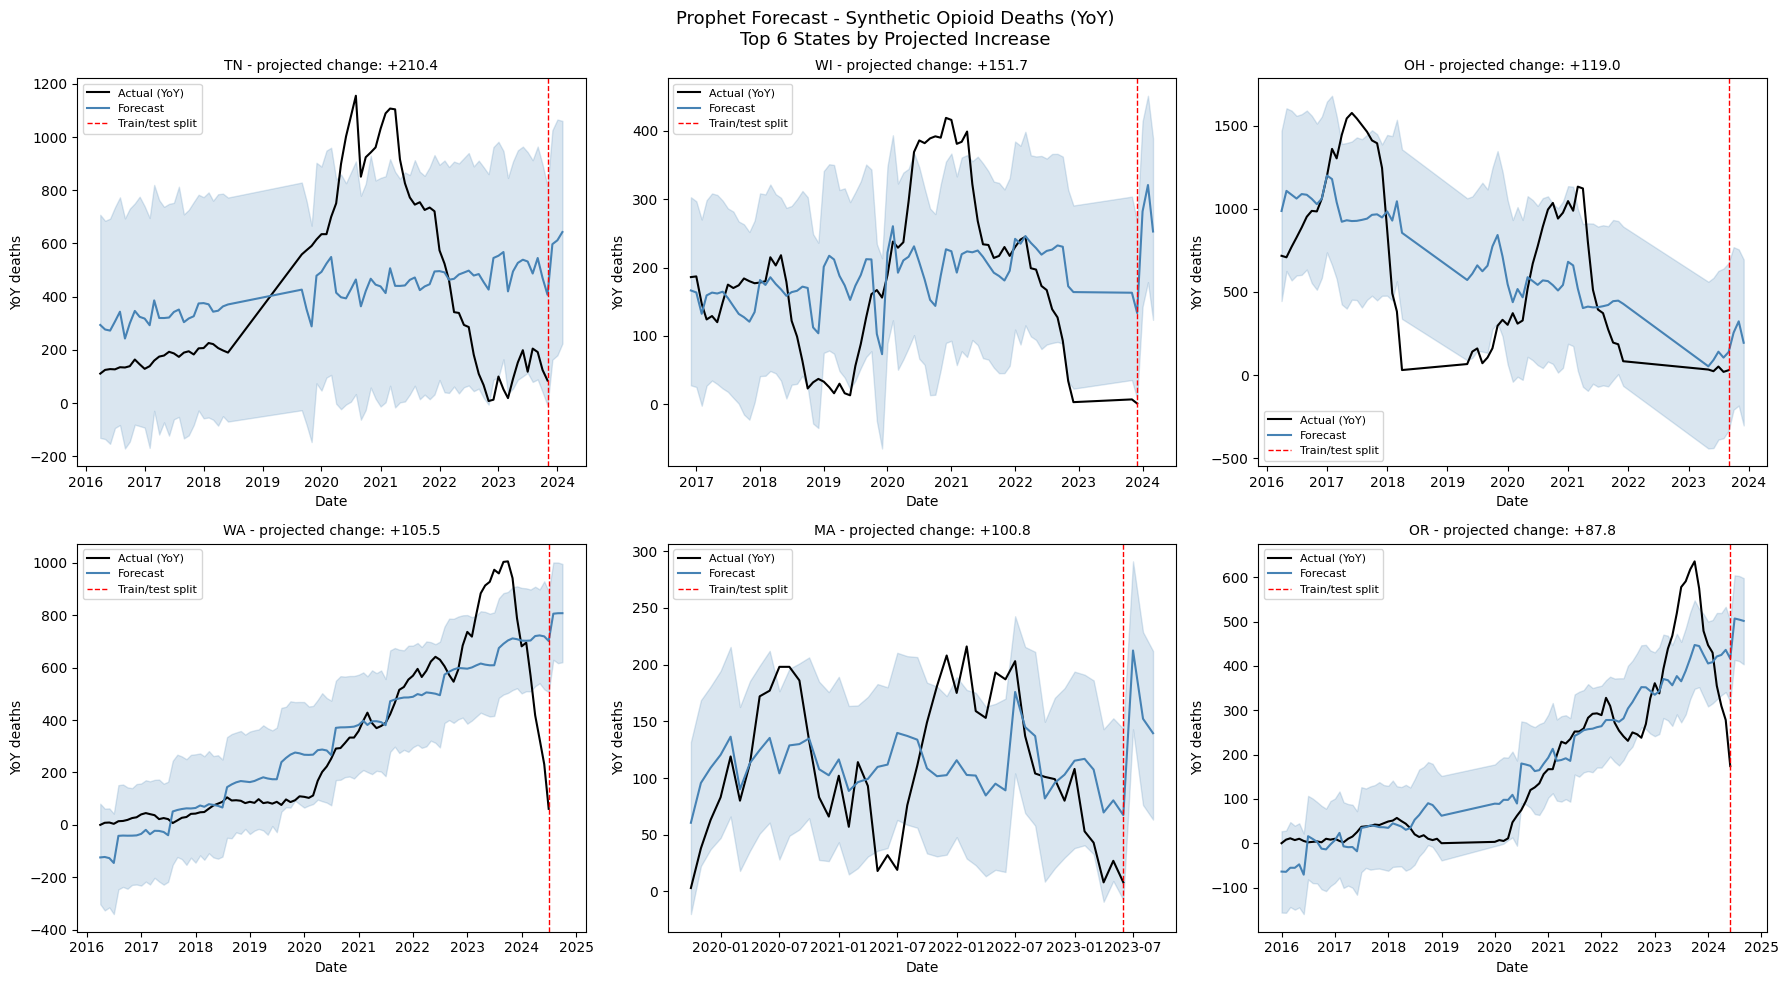

saved to outputs/prophet_top6_states.png


In [28]:

top_states = summary.head(6)['State'].tolist()

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for idx, state in enumerate(top_states):
    r = results[state]
    ax = axes[idx]
    ax.plot(r['actual']['ds'], r['actual']['y'], label='Actual (YoY)', color='black', linewidth=1.5)
    ax.plot(r['forecast']['ds'], r['forecast']['yhat'], label='Forecast', color='steelblue', linewidth=1.5)
    ax.fill_between(r['forecast']['ds'], r['forecast']['yhat_lower'], r['forecast']['yhat_upper'],
                    alpha=0.2, color='steelblue')
    ax.axvline(r['train_end'], color='red', linestyle='--', linewidth=1, label='Train/test split')
    ax.set_title(f"{state} - projected change: {r['projected_change']:+.1f}", fontsize=10)
    ax.set_xlabel('Date')
    ax.set_ylabel('YoY deaths')
    ax.legend(fontsize=8)

plt.suptitle('Prophet Forecast - Synthetic Opioid Deaths (YoY)\nTop 6 States by Projected Increase', fontsize=13)
plt.tight_layout()
plt.savefig('../../outputs/prophet_top6_states.png', dpi=150)
plt.show()
print('saved to outputs/prophet_top6_states.png')

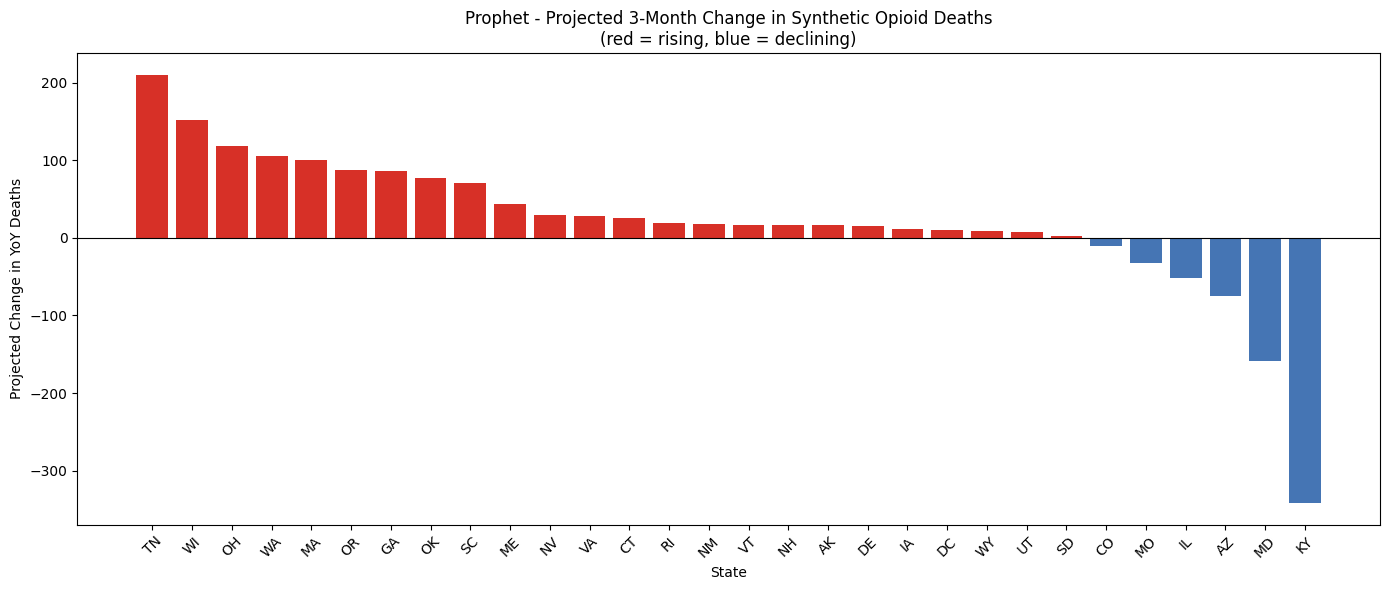

saved to outputs/prophet_state_ranking.png


In [29]:
# early warning bar chart
fig, ax = plt.subplots(figsize=(14, 6))
colors = ['#d73027' if x > 0 else '#4575b4' for x in summary['Projected Change (3mo)']]
ax.bar(summary['State'], summary['Projected Change (3mo)'], color=colors)
ax.axhline(0, color='black', linewidth=0.8)
ax.set_title('Prophet - Projected 3-Month Change in Synthetic Opioid Deaths\n(red = rising, blue = declining)', fontsize=12)
ax.set_xlabel('State')
ax.set_ylabel('Projected Change in YoY Deaths')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('../../outputs/prophet_state_ranking.png', dpi=150)
plt.show()
print('saved to outputs/prophet_state_ranking.png')